## Aim: To implement Neural Style Transfer (NST) using Deep Learning techniques to generate artistic images by combining the content of one image with the style of another image.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import vgg19

# ==========================================
# 1. Choose Content and S tyle Images
# ==========================================
def load_and_process_image(image_path, max_dim=512):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Scale the image while keeping the aspect ratio
    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tf.cast(shape * scale, tf.int32)
    
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :] # Add batch dimension
    return img

print("Downloading Sample Images...")
content_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

content_image = load_and_process_image(content_path)
style_image = load_and_process_image(style_path)




In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import vgg19

# ==========================================
# 1. Choose Content and Style Images
# ==========================================
def load_and_process_image(image_path, max_dim=512):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    # Scale the image while keeping the aspect ratio
    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tf.cast(shape * scale, tf.int32)
    
    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :] # Add batch dimension
    return img

print("Downloading Sample Images...")
content_path = tf.keras.utils.get_file('YellowLabradorLooking_new.jpg', 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg')
style_path = tf.keras.utils.get_file('kandinsky5.jpg','https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

content_image = load_and_process_image(content_path)
style_image = load_and_process_image(style_path)




83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


In [2]:
# ==========================================
# 2. Preprocess Images & Load VGG19
# ==========================================
# Define which layers of VGG19 represent "Style" and which represent "Content"
content_layers = ['block5_conv2'] 
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

def get_vgg_model(style_layers, content_layers):
    # Load VGG19 trained on ImageNet, without the classification head
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    
    # Get the outputs of the specific layers we chose
    style_outputs = [vgg.get_layer(name).output for name in style_layers]
    content_outputs = [vgg.get_layer(name).output for name in content_layers]
    model_outputs = style_outputs + content_outputs
    
    return tf.keras.Model([vgg.input], model_outputs)

vgg_model = get_vgg_model(style_layers, content_layers)




80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [3]:
# ==========================================
# 3. Define Loss Functions
# ==========================================
def gram_matrix(input_tensor):
    # This calculates the style/texture correlations
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / (num_locations)

class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = get_vgg_model(style_layers, content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    def call(self, inputs):
        # Preprocess input explicitly for VGG19
        inputs = inputs * 255.0
        preprocessed_input = vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed_input)
        
        style_outputs, content_outputs = (outputs[:self.num_style_layers], outputs[self.num_style_layers:])
        style_outputs = [gram_matrix(style_output) for style_output in style_outputs]
        
        content_dict = {content_name: value for content_name, value in zip(self.content_layers, content_outputs)}
        style_dict = {style_name: value for style_name, value in zip(self.style_layers, style_outputs)}
        return {'content': content_dict, 'style': style_dict}

extractor = StyleContentModel(style_layers, content_layers)

# Extract targets (what we want our generated image to match)
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

# Initialize the generated image as the content image
generated_image = tf.Variable(content_image)


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_22']
Received: inputs=Tensor(shape=(1, 336, 512, 3))
  warnings.warn(msg)
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_22']
Received: inputs=Tensor(shape=(1, 422, 512, 3))
  warnings.warn(msg)


In [4]:
# ==========================================
# 4. Optimization
# ==========================================
# Weights to balance how much content vs. how much style you want
style_weight = 1e-2
content_weight = 1e4

optimizer = tf.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

@tf.function() # Compiles this function into a fast TensorFlow graph
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        
        # Calculate Style Loss
        style_loss = tf.add_n([tf.reduce_mean((outputs['style'][name] - style_targets[name])**2) 
                               for name in outputs['style'].keys()])
        style_loss *= style_weight / num_style_layers
        
        # Calculate Content Loss
        content_loss = tf.add_n([tf.reduce_mean((outputs['content'][name] - content_targets[name])**2) 
                                 for name in outputs['content'].keys()])
        content_loss *= content_weight / num_content_layers
        
        # Total Loss
        loss = style_loss + content_loss

    # Calculate gradients and update the image
    grad = tape.gradient(loss, image)
    optimizer.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0))


In [5]:
# ==========================================
# 5. Generate Artistic Image
# ==========================================
print("Starting Optimization Loop (This takes time on a CPU)...")

epochs = 5      # Increase this for a better final image (e.g., 10 or 20)
steps_per_epoch = 20 # How many gradient steps per epoch

for n in range(epochs):
    for m in range(steps_per_epoch):
        train_step(generated_image)
    print(f"Epoch {n+1}/{epochs} completed.")



Starting Optimization Loop (This takes time on a CPU)...
Epoch 1/5 completed.
Epoch 2/5 completed.
Epoch 3/5 completed.
Epoch 4/5 completed.
Epoch 5/5 completed.


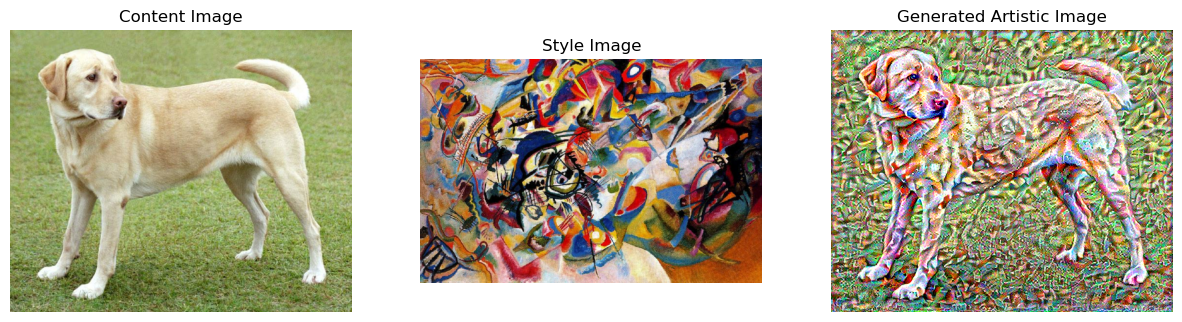

Conclusion: Neural Style Transfer Successfully Implemented.


In [6]:
# Display Results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Content Image")
plt.imshow(tf.squeeze(content_image))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Style Image")
plt.imshow(tf.squeeze(style_image))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Generated Artistic Image")
plt.imshow(tf.squeeze(generated_image.numpy()))
plt.axis('off')

plt.show()
print("Conclusion: Neural Style Transfer Successfully Implemented.")